# Olist Customer Retention & Cohort Analysis
**Project:** E-Commerce Customer & Sales Analytics · **Tools:** Python (Pandas), DuckDB SQL, Matplotlib

### Learning goals
1. Understand repeat customer rate vs cohort retention.
2. Build a cohort table using `customer_unique_id`.
3. Create a Month 0–Month 6 retention heatmap.
4. Export a clean Tableau-ready CSV for the dashboard.

**Analytical choices**
- Use orders whose *final status* is `delivered`.
- Group buyers by the month of `order_purchase_timestamp` (not delivery date).
- For comparable reporting, include purchases **through August 31, 2018**. Results may differ slightly from Lesson 3, which used the full dataset.
- A returning buyer is counted once per month; multiple orders within the same month do not inflate retention.
- A blank future cell is **not** zero retention. Recent cohorts have not had enough time to mature.
- The dataset is observational and historical. No causal conclusions.

## 1 · Install packages and upload Olist CSVs

In [1]:
%pip -q install duckdb
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files

print('DuckDB version:', duckdb.__version__)
print('Upload the two CSVs: orders and customers.')
uploaded = files.upload()
required = {'olist_orders_dataset.csv', 'olist_customers_dataset.csv'}
missing = required - {p.name for p in Path('.').glob('*.csv')}
assert not missing, f'Missing files: {sorted(missing)}'
print('Both files available.')

DuckDB version: 1.3.2
Upload the two CSVs: orders and customers.


Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Both files available.


## 2 · Read the data and inspect the key columns

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
print('Orders:', orders.shape, '| Customers:', customers.shape)
display(orders[['order_id','customer_id','order_status','order_purchase_timestamp']].head())
display(customers[['customer_id','customer_unique_id']].head())
print('Duplicate order_id:', orders['order_id'].duplicated().sum())
print('Duplicate customer_id in customers:', customers['customer_id'].duplicated().sum())

Orders: (99441, 8) | Customers: (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39


,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


Duplicate order_id: 0
Duplicate customer_id in customers: 0


## 3 · Register tables and build views in DuckDB

DuckDB can query the CSVs without installing a database server. The SQL transformations are also saved as `04_customer_cohort_retention.sql`.

In [3]:
con = duckdb.connect()
con.execute("CREATE OR REPLACE VIEW orders AS SELECT * FROM read_csv_auto('olist_orders_dataset.csv', header=true)")
con.execute("CREATE OR REPLACE VIEW customers AS SELECT * FROM read_csv_auto('olist_customers_dataset.csv', header=true)")
print(con.sql("SELECT COUNT(*) AS orders FROM orders").df())

   orders
0   99441


In [4]:
# Source delivered-order events; one row per eligible order.
con.execute("""CREATE OR REPLACE VIEW v_delivered_customer_orders AS
SELECT
    o.order_id,
    c.customer_unique_id,
    TRY_CAST(o.order_purchase_timestamp AS TIMESTAMP) AS purchase_ts,
    DATE_TRUNC('month', TRY_CAST(o.order_purchase_timestamp AS TIMESTAMP))::DATE AS purchase_month
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND c.customer_unique_id IS NOT NULL
  AND TRY_CAST(o.order_purchase_timestamp AS TIMESTAMP) IS NOT NULL
  AND TRY_CAST(o.order_purchase_timestamp AS TIMESTAMP) < TIMESTAMP '2018-09-01 00:00:00';""")
con.sql("""SELECT COUNT(*) AS delivered_orders_through_aug_2018,
                  COUNT(DISTINCT customer_unique_id) AS unique_customers
           FROM v_delivered_customer_orders""").df()

,delivered_orders_through_aug_2018,unique_customers
0,96478,93358


In [5]:
# Unique active customer-months and first-month cohort.
con.execute("""CREATE OR REPLACE VIEW v_customer_months AS
SELECT DISTINCT customer_unique_id, purchase_month
FROM v_delivered_customer_orders;""")
con.execute("""CREATE OR REPLACE VIEW v_customer_cohorts AS
WITH first_month AS (
    SELECT customer_unique_id, MIN(purchase_month) AS cohort_month
    FROM v_customer_months
    GROUP BY customer_unique_id
)
SELECT
    cm.customer_unique_id,
    fm.cohort_month,
    cm.purchase_month,
    DATE_DIFF('month', fm.cohort_month, cm.purchase_month) AS month_number
FROM v_customer_months cm
JOIN first_month fm USING (customer_unique_id);""")
display(con.sql("SELECT * FROM v_customer_cohorts ORDER BY cohort_month, customer_unique_id LIMIT 10").df())

,customer_unique_id,cohort_month,purchase_month,month_number
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-01,2016-09-01,0
1,0032c76b20340da25249092a268ce66c,2016-10-01,2016-10-01,0
2,01f156677184504063bd19739f924af1,2016-10-01,2016-10-01,0
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10-01,2016-10-01,0
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10-01,2016-10-01,0
5,0829f7df6577d5a4b65439bea701405f,2016-10-01,2016-10-01,0
6,08da95f931937b2c20f5225f2e6c93b0,2016-10-01,2016-10-01,0
7,0922f37485310929b1b94e8f0c984ca5,2016-10-01,2016-10-01,0
8,0a02ba4243b1b0e048a3841d5758d113,2016-10-01,2016-10-01,0
9,0ac6c084c9623a0e2ace60297ad24d6c,2016-10-01,2016-10-01,0


## 4 · Calculate cohort retention

**Cohort size:** number of unique buyers whose first observed delivered purchase occurred in that month.

**Month 1 retention:** buyers from that cohort who also placed a delivered order in the *next calendar month* / cohort size.

Month 0 is always 100% by definition. Blank cells mean the relevant future month falls outside our observation window.

In [6]:
con.execute("""CREATE OR REPLACE VIEW v_cohort_retention AS
WITH cohort_sizes AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS cohort_size
    FROM v_customer_cohorts
    WHERE month_number = 0
    GROUP BY cohort_month
),
active_by_age AS (
    SELECT cohort_month, month_number,
           COUNT(DISTINCT customer_unique_id) AS active_customers
    FROM v_customer_cohorts
    GROUP BY cohort_month, month_number
),
ages AS (
    SELECT range AS month_number
    FROM range(0, 7)
)
SELECT
    c.cohort_month,
    a.month_number,
    c.cohort_size,
    COALESCE(x.active_customers, 0) AS active_customers,
    ROUND(100.0 * COALESCE(x.active_customers, 0)
          / NULLIF(c.cohort_size, 0), 2) AS retention_pct
FROM cohort_sizes c
CROSS JOIN ages a
LEFT JOIN active_by_age x
    ON x.cohort_month = c.cohort_month
   AND x.month_number = a.month_number
WHERE a.month_number <= DATE_DIFF('month', c.cohort_month, DATE '2018-08-01');""")
cohorts = con.sql("SELECT * FROM v_cohort_retention ORDER BY cohort_month, month_number").df()
display(cohorts.head(12))

,cohort_month,month_number,cohort_size,active_customers,retention_pct
0,2016-09-01,0,1,1,100.0
1,2016-09-01,1,1,0,0.0
2,2016-09-01,2,1,0,0.0
3,2016-09-01,3,1,0,0.0
4,2016-09-01,4,1,0,0.0
5,2016-09-01,5,1,0,0.0
6,2016-09-01,6,1,0,0.0
7,2016-10-01,0,262,262,100.0
8,2016-10-01,1,262,0,0.0
9,2016-10-01,2,262,0,0.0


## 5 · Validate calculations (very important!)

In [7]:
month0 = cohorts[cohorts['month_number'] == 0]
assert len(month0) > 0
assert (month0['retention_pct'] == 100).all(), 'Month 0 should be 100%'
assert (cohorts['active_customers'] <= cohorts['cohort_size']).all()
assert cohorts['retention_pct'].between(0,100).all()
print('✅ Month 0 is 100% for every cohort')
print('✅ Active customers <= cohort size')
print('✅ All retention rates between 0% and 100%')

repeat_summary = con.sql("""
WITH per_customer AS (
    SELECT customer_unique_id, COUNT(DISTINCT order_id) AS n_orders
    FROM v_delivered_customer_orders GROUP BY 1
)
SELECT COUNT(*) AS unique_customers,
       COUNT(*) FILTER (WHERE n_orders > 1) AS repeat_customers,
       ROUND(100.0 * COUNT(*) FILTER (WHERE n_orders > 1) / NULLIF(COUNT(*),0), 2) AS repeat_rate_pct
FROM per_customer
""").df()
display(repeat_summary)
print('Note: numbers may differ from Lesson 3 due to the August 2018 cutoff.')

✅ Month 0 is 100% for every cohort
✅ Active customers <= cohort size
✅ All retention rates between 0% and 100%


,unique_customers,repeat_customers,repeat_rate_pct
0,93358,2801,3.0


Note: numbers may differ from Lesson 3 due to the August 2018 cutoff.


## 6 · Make a retention matrix and heatmap (Months 0–6)

month_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.38
2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36


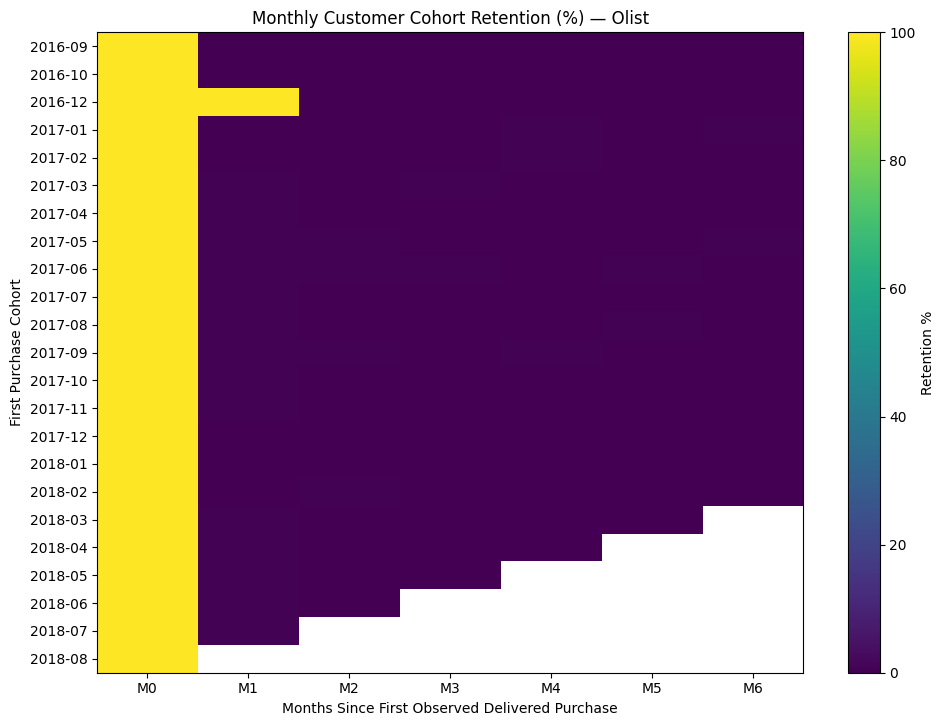

In [8]:
matrix = cohorts.pivot(index='cohort_month', columns='month_number', values='retention_pct')
matrix.index = pd.to_datetime(matrix.index).strftime('%Y-%m')
display(matrix.round(2))

fig, ax = plt.subplots(figsize=(10, max(5, len(matrix) * 0.32)))
plot_data = np.ma.masked_invalid(matrix.to_numpy(dtype=float))
im = ax.imshow(plot_data, aspect='auto')
ax.set_xticks(range(len(matrix.columns)), labels=[f'M{i}' for i in matrix.columns])
ax.set_yticks(range(len(matrix.index)), labels=list(matrix.index))
ax.set_title('Monthly Customer Cohort Retention (%) — Olist')
ax.set_xlabel('Months Since First Observed Delivered Purchase')
ax.set_ylabel('First Purchase Cohort')
fig.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.show()

## 7 · Find the patterns
Monthly cohort retention is not necessarily cumulative. A buyer can return in M2 without buying in M1, so individual rows don't have to fall monotonically.

In [9]:
# Starter queries to answer questions 1–3
print('January 2018:')
display(con.sql("SELECT * FROM v_cohort_retention WHERE cohort_month = DATE '2018-01-01' AND month_number IN (0, 1)").df())
print('2017 Month 1 cohorts:')
display(con.sql("""
SELECT cohort_month, cohort_size, retention_pct
FROM v_cohort_retention
WHERE month_number = 1 AND cohort_month >= DATE '2017-01-01'
      AND cohort_month < DATE '2018-01-01'
ORDER BY retention_pct DESC
""").df())

January 2018:


,cohort_month,month_number,cohort_size,active_customers,retention_pct
0,2018-01-01,1,6842,23,0.34
1,2018-01-01,0,6842,6842,100.00


2017 Month 1 cohorts:


,cohort_month,cohort_size,retention_pct
0,2017-10-01,4328,0.72
1,2017-09-01,4004,0.70
2,2017-08-01,4057,0.69
3,2017-04-01,2256,0.62
4,2017-11-01,7060,0.57
5,2017-07-01,3752,0.53
6,2017-06-01,3037,0.49
7,2017-05-01,3451,0.46
8,2017-03-01,2503,0.44
9,2017-01-01,717,0.28


## 8 · Export Tableau-ready cohort table
We export **one row per cohort and month index** with `cohort_size`, `active_customers`, and `retention_pct`. In Tableau, use `cohort_month` on Rows, `month_number` on Columns, and `retention_pct` on Color/Label.


In [10]:
cohorts.to_csv('olist_cohort_retention_tableau.csv', index=False)
print('Saved rows:', len(cohorts))
print('File: olist_cohort_retention_tableau.csv')
files.download('olist_cohort_retention_tableau.csv')

Saved rows: 140
File: olist_cohort_retention_tableau.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9 · Next: GitHub & Tableau


Data source: [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).